In [1]:
import numpy as np
x = np.array([1, 2, 3])
W = np.array([[1, 0, 2], [3, 1, 0]])
y = np.dot(W, x)
print(y)
# le transpose de W
W_transpose = W.T
print(W_transpose)


[7 5]
[[1 3]
 [0 1]
 [2 0]]


In [2]:
# Exercice : Vrai exemple DNN
# x = image de 784 pixels (28x28 aplatie)
# W = 100 neurones cachés × 784 entrées
x_image = np.random.rand(784)  # Simuler une image aléatoire
W_couche = np.random.rand(100, 784)  # Simuler des poids aléatoires pour la couche cachée
sortie_couche = np.dot(W_couche, x_image)  # Calculer la sortie de la couche cachée
print(sortie_couche)

[191.21556268 187.01350012 197.93445189 188.40275639 195.87655643
 200.20487185 192.54597692 200.9844674  199.31213646 200.49498613
 201.98985658 194.74382244 198.1902008  197.11209294 192.10419357
 193.44245403 198.65310221 199.43670976 187.20950141 189.42400178
 195.41022948 195.78837206 204.03152025 191.00081565 196.58822411
 191.06034393 192.4642833  189.78636926 200.14669296 198.99180902
 192.31039914 196.11033387 196.13271777 194.08530525 196.5174565
 198.84821862 196.92616792 197.32588358 183.261891   191.29377675
 200.33134668 198.25531862 192.1955727  190.6501013  182.47922349
 199.03266744 197.59134835 193.25436066 196.46485359 199.65728082
 191.91431976 198.4394942  195.60485067 190.6367304  194.16317132
 193.82867432 190.51188775 199.67476536 189.08942504 189.74945486
 199.94771595 192.76836342 200.62916538 196.12998271 196.34761918
 192.61412408 191.48906561 199.1733014  192.36490808 194.26976586
 192.91010755 184.317817   192.73593767 196.32062306 198.73234621
 192.985402

Étape 1: x=3.8000, f(x)=23.0400
Étape 2: x=2.8400, f(x)=14.7456
Étape 3: x=2.0720, f(x)=9.4372
Étape 4: x=1.4576, f(x)=6.0398
Étape 5: x=0.9661, f(x)=3.8655
Étape 6: x=0.5729, f(x)=2.4739
Étape 7: x=0.2583, f(x)=1.5833
Étape 8: x=0.0066, f(x)=1.0133
Étape 9: x=-0.1947, f(x)=0.6485
Étape 10: x=-0.3558, f(x)=0.4151
Étape 11: x=-0.4846, f(x)=0.2656
Étape 12: x=-0.5877, f(x)=0.1700
Étape 13: x=-0.6701, f(x)=0.1088
Étape 14: x=-0.7361, f(x)=0.0696
Étape 15: x=-0.7889, f(x)=0.0446
Étape 16: x=-0.8311, f(x)=0.0285
Étape 17: x=-0.8649, f(x)=0.0183
Étape 18: x=-0.8919, f(x)=0.0117
Étape 19: x=-0.9135, f(x)=0.0075
Étape 20: x=-0.9308, f(x)=0.0048


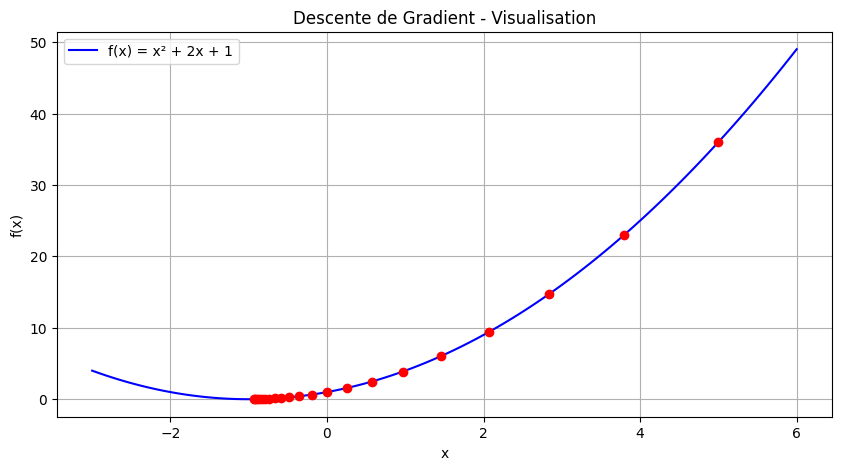


Minimum trouvé: x=-0.9308 (vrai minimum: x=-1)


In [3]:
# Dérivées & Gradients 
import numpy as np
import matplotlib.pyplot as plt

# Visualiser la descente de gradient
def f(x):
    return x**2 + 2*x + 1  # (x+1)²

def df(x):
    return 2*x + 2  # dérivée

# Descente de gradient
x = 5.0  # point de départ
lr = 0.1  # learning rate
historique = [x]

for i in range(20):
   gradient = df(x)
   x = x - lr * gradient  # mise à jour de x
   historique.append(x) # stocker l'historique pour visualisation
   print(f"Étape {i+1}: x={x:.4f}, f(x)={f(x):.4f}")
# Visualisation
x_range = np.linspace(-3, 6, 100)
plt.figure(figsize=(10, 5))
plt.plot(x_range, f(x_range), 'b-', label='f(x) = x² + 2x + 1')
plt.scatter(historique, [f(x) for x in historique], c='red', zorder=5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Descente de Gradient - Visualisation')
plt.legend()
plt.grid(True)
plt.savefig('gradient_descent.png')
plt.show()
print(f"\nMinimum trouvé: x={x:.4f} (vrai minimum: x=-1)")

In [4]:
# Softmax et probabilités
import numpy as np

def softmax(z):
    """Convertit des scores en probabilités (somme = 1)"""
    e_z = np.exp(z - np.max(z))  # soustraction pour stabilité numérique
    return e_z / e_z.sum()

# Exemple: réseau dit [2.1, 1.5, 0.3] pour [chien, chat, oiseau]
scores = np.array([2.1, 1.5, 0.3])
probas = softmax(scores)
print("Probabilités:", probas)
# Ex: [0.65, 0.32, 0.12] → 65% chien, 32% chat, 12% oiseau


Probabilités: [0.58339295 0.32017284 0.09643421]


In [5]:
import numpy as np

class Neurone:
    """Un seul neurone artificiel"""
    
    def __init__(self, n_entrees):
        # Initialisation aléatoire des poids (petits nombres)
        self.poids = np.random.randn(n_entrees) * 0.1
        self.biais = 0.0
    
    def activation_sigmoid(self, z):
        """Sigmoid: compresse la sortie entre 0 et 1"""
        return 1 / (1 + np.exp(-z))
    
    def forward(self, x):
        """Propagation avant: calculer la sortie"""
        z = np.dot(self.poids, x) + self.biais  # z = W·x + b
        return self.activation_sigmoid(z)
    
    def train_un_exemple(self, x, y_vrai, lr=0.1):
        """Entraîner sur UN seul exemple"""
        # 1. Prédire
        y_pred = self.forward(x)
        
        # 2. Calculer l'erreur
        erreur = y_vrai - y_pred
        
        # 3. Mettre à jour les poids (règle delta)
        self.poids += lr * erreur * x
        self.biais += lr * erreur
        
        return erreur

# Test: apprendre la fonction AND
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])  # AND: vrai seulement si les deux sont 1

neurone = Neurone(n_entrees=2)

# Entraînement
for epoch in range(100):
    erreur_totale = 0
    for xi, yi in zip(X, y):
        erreur_totale += abs(neurone.train_un_exemple(xi, yi))
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Erreur totale: {erreur_totale:.4f}")

# Test final
print("\nPrédictions finales:")
for xi, yi in zip(X, y):
    pred = neurone.forward(xi)
    print(f"  {xi} → prédit: {pred:.3f}, vrai: {yi}")


Epoch 0, Erreur totale: 2.0234
Epoch 20, Erreur totale: 1.5221
Epoch 40, Erreur totale: 1.2826
Epoch 60, Erreur totale: 1.1149
Epoch 80, Erreur totale: 0.9898

Prédictions finales:
  [0 0] → prédit: 0.050, vrai: 0
  [0 1] → prédit: 0.241, vrai: 0
  [1 0] → prédit: 0.247, vrai: 0
  [1 1] → prédit: 0.663, vrai: 1
